In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("netflix_titles.csv")

# Basic shape and structure
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# Preview
df.head()

Shape: (8807, 12)

Column names:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Detailed info
df.info()

# Missing values per column
print("\nMissing values:\n", df.isnull().sum())

# Missing value percentage
print("\nMissing % :\n", (df.isnull().sum() / len(df) * 100).round(2))

# Basic stats for numeric columns
df.describe()

# Duplicate rows check
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
des

In [3]:
# Look at rows with missing rating or duration
print(df[df['duration'].isnull()][['title','type','rating','duration']])
print(df[df['rating'].isnull()][['title','type','rating','duration']])

# Check unique rating values for weirdness
print(df['rating'].unique())

                                     title   type  rating duration
5541                       Louis C.K. 2017  Movie  74 min      NaN
5794                 Louis C.K.: Hilarious  Movie  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  Movie  66 min      NaN
                                                  title     type rating  \
5989  13TH: A Conversation with Oprah Winfrey & Ava ...    Movie    NaN   
6827                  Gargantia on the Verdurous Planet  TV Show    NaN   
7312                                       Little Lunch  TV Show    NaN   
7537                               My Honor Was Loyalty    Movie    NaN   

      duration  
5989    37 min  
6827  1 Season  
7312  1 Season  
7537   115 min  
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']


In [4]:
# Step 1: Fix the 3 rows where duration value leaked into 'rating' column
mask = df['rating'].isin(['74 min', '84 min', '66 min'])
df.loc[mask, 'duration'] = df.loc[mask, 'rating']   # move value to correct column
df.loc[mask, 'rating'] = np.nan                      # clear the wrong column

# Confirm fix
print(df.loc[mask, ['title','type','rating','duration']])

# Step 2: Handle remaining missing values
# country -> fill with 'Unknown' (too many real gaps to drop)
df['country'] = df['country'].fillna('Unknown')

# director / cast -> fill with 'Unknown' (dropping would lose ~30% of rows)
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# rating -> fill with mode (most common rating)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# date_added -> drop the 10 rows missing it (negligible, and we need it as a date)
df = df.dropna(subset=['date_added'])

# duration -> should now have 0 nulls after the fix above; drop any stragglers just in case
df = df.dropna(subset=['duration'])

# Confirm no more missing values
print("\nRemaining missing values:\n", df.isnull().sum())
print("\nNew shape:", df.shape)

                                     title   type rating duration
5541                       Louis C.K. 2017  Movie    NaN   74 min
5794                 Louis C.K.: Hilarious  Movie    NaN   84 min
5813  Louis C.K.: Live at the Comedy Store  Movie    NaN   66 min

Remaining missing values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

New shape: (8797, 12)


In [5]:
# Step 3: Clean up date_added (strip whitespace, convert to datetime)
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

# Step 4: Split duration into number + unit (Movies = min, TV Shows = Seasons)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)
df['duration_unit'] = df['duration'].str.extract('([a-zA-Z]+)')

# Quick check
df[['type','duration','duration_num','duration_unit']].sample(5)

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_34052\1843413947.py:6: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)


,type,duration,duration_num,duration_unit
978,Movie,102 min,102,min
7449,TV Show,1 Season,1,Season
8640,Movie,76 min,76,min
4625,Movie,117 min,117,min
8165,TV Show,1 Season,1,Season


In [6]:
# 1. Count of Movies vs TV Shows
type_counts = df['type'].value_counts()
print(type_counts)

# 2. Percentage distribution
type_pct = df['type'].value_counts(normalize=True) * 100
print("\nPercentage distribution:\n", type_pct.round(2))

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Percentage distribution:
 type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


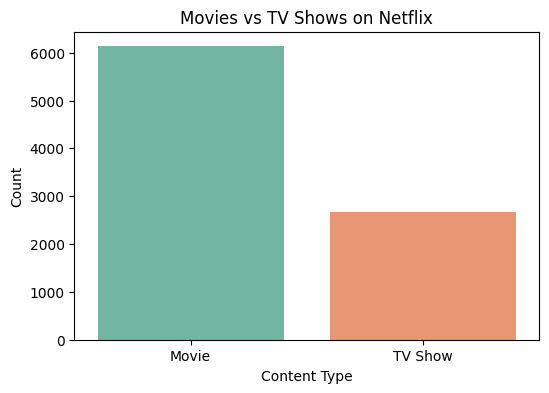

In [7]:
# Visualization 1: Count Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

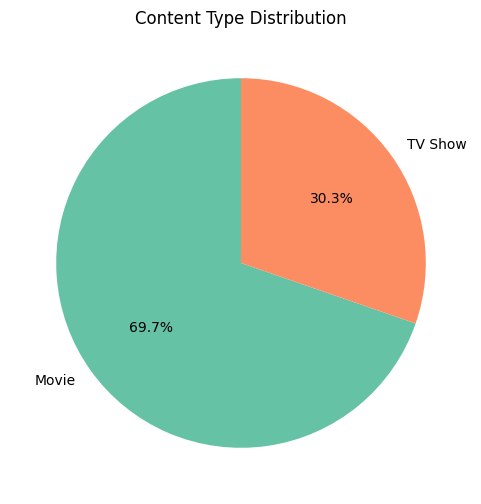

In [8]:
# Visualization 2: Pie Chart
plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'), startangle=90)
plt.title('Content Type Distribution')
plt.show()

In [9]:
# 1. Top 10 content-producing countries
# Note: 'country' can have multiple countries per row (comma-separated), so we split them
all_countries = df['country'].str.split(', ').explode()

top10_countries = all_countries.value_counts().head(10)
print(top10_countries)

country
United States     3683
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


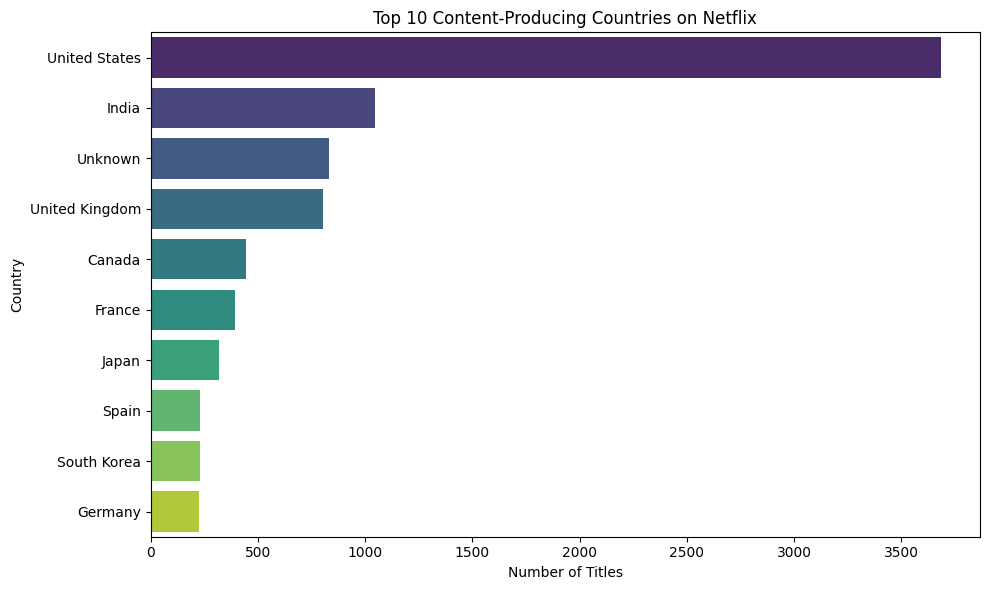

In [10]:
# 2. Visualize country distribution - Bar Chart
plt.figure(figsize=(10,6))
sns.barplot(x=top10_countries.values, y=top10_countries.index, hue=top10_countries.index,
            palette='viridis', legend=False)
plt.title('Top 10 Content-Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [11]:
# Top 10 countries, excluding 'Unknown'
top10_countries_clean = all_countries[all_countries != 'Unknown'].value_counts().head(10)
print(top10_countries_clean)

country
United States     3683
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


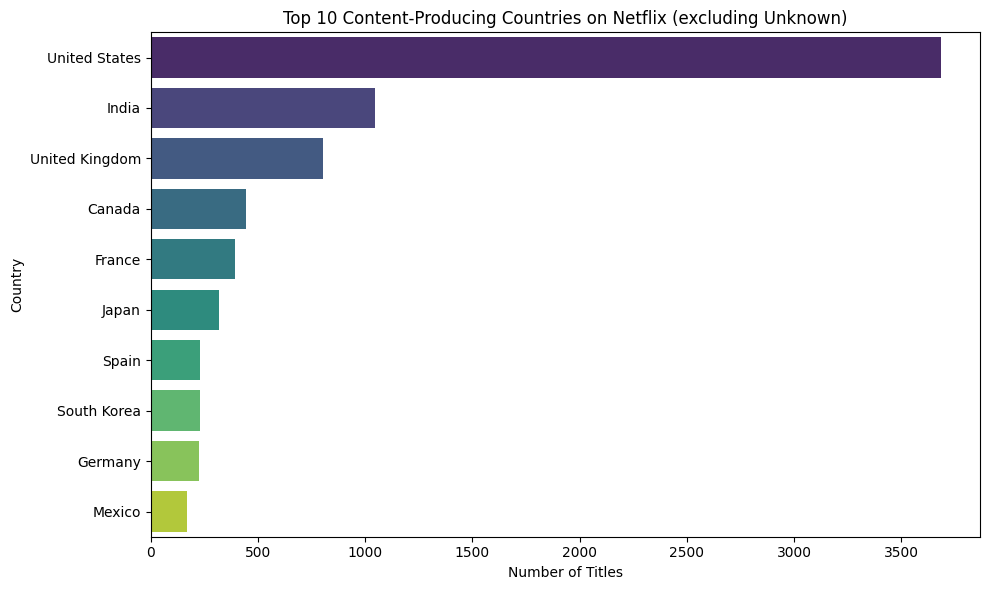

In [12]:
# Re-plot with clean data
plt.figure(figsize=(10,6))
sns.barplot(x=top10_countries_clean.values, y=top10_countries_clean.index,
            hue=top10_countries_clean.index, palette='viridis', legend=False)
plt.title('Top 10 Content-Producing Countries on Netflix (excluding Unknown)')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [13]:
# 1. Number of titles released each year (using release_year)
yearly_counts = df['release_year'].value_counts().sort_index()
print(yearly_counts.tail(15))  # focus on recent years, older ones are sparse/noisy

release_year
2007      88
2008     135
2009     152
2010     193
2011     185
2012     236
2013     287
2014     352
2015     558
2016     901
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64


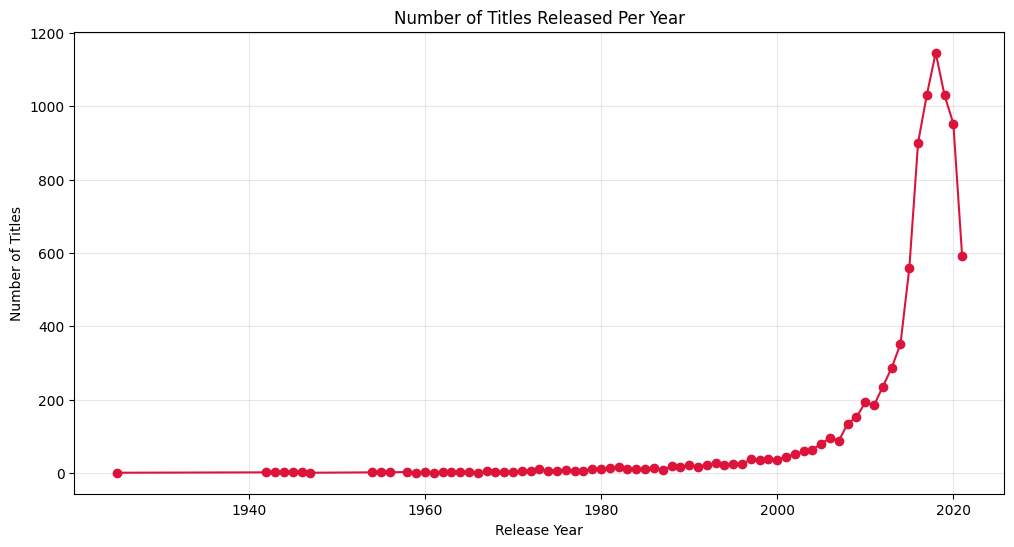

In [14]:
# Visualization 1: Line Chart - overall trend
plt.figure(figsize=(12,6))
yearly_counts.plot(kind='line', marker='o', color='crimson')
plt.title('Number of Titles Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(alpha=0.3)
plt.show()

In [15]:
# 2. Has content production increased over time? - quick numeric check
print("Earliest year:", df['release_year'].min())
print("Peak year:", yearly_counts.idxmax(), "with", yearly_counts.max(), "titles")
print("\nGrowth comparison - 2015 vs 2019:")
print(yearly_counts.loc[[2015, 2019]])

Earliest year: 1925
Peak year: 2018 with 1146 titles

Growth comparison - 2015 vs 2019:
release_year
2015     558
2019    1030
Name: count, dtype: int64


In [16]:
# 1. Most common maturity rating
rating_counts = df['rating'].value_counts()
print(rating_counts)

print("\nMost common rating:", rating_counts.idxmax(), "with", rating_counts.max(), "titles")

rating
TV-MA       3212
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

Most common rating: TV-MA with 3212 titles


In [17]:
# 2. Distribution of ratings (as percentage)
rating_pct = df['rating'].value_counts(normalize=True) * 100
print(rating_pct.round(2))

rating
TV-MA       36.51
TV-14       24.52
TV-PG        9.79
R            9.08
PG-13        5.57
TV-Y7        3.79
TV-Y         3.48
PG           3.26
TV-G         2.50
NR           0.90
G            0.47
TV-Y7-FV     0.07
NC-17        0.03
UR           0.03
Name: proportion, dtype: float64


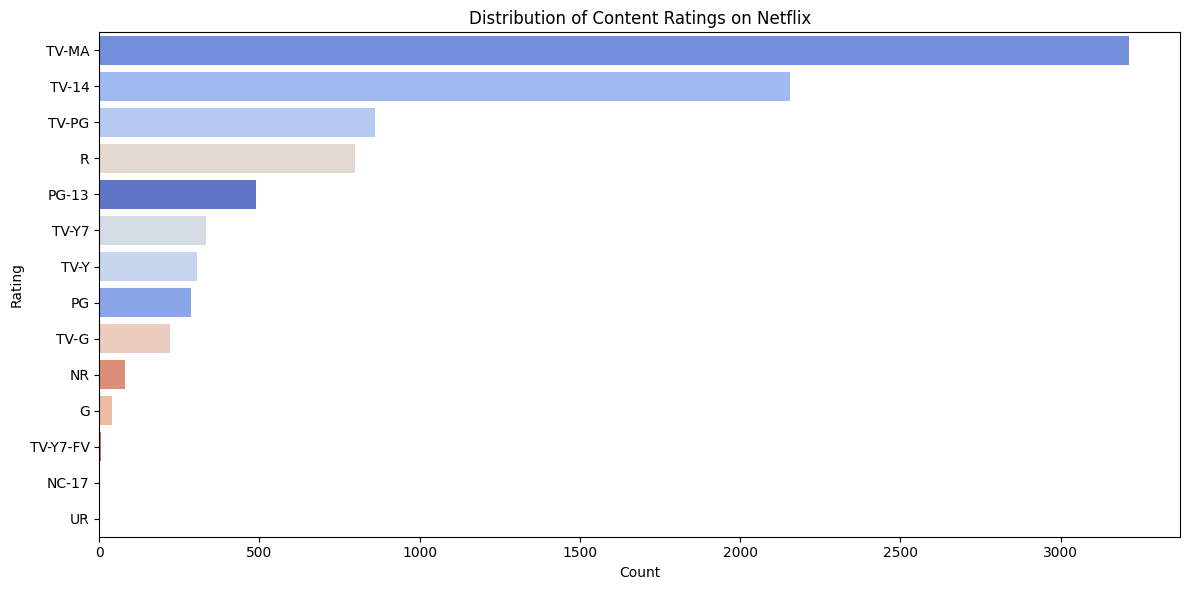

In [18]:
# 3. Visualize using countplot
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index,
              hue='rating', palette='coolwarm', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

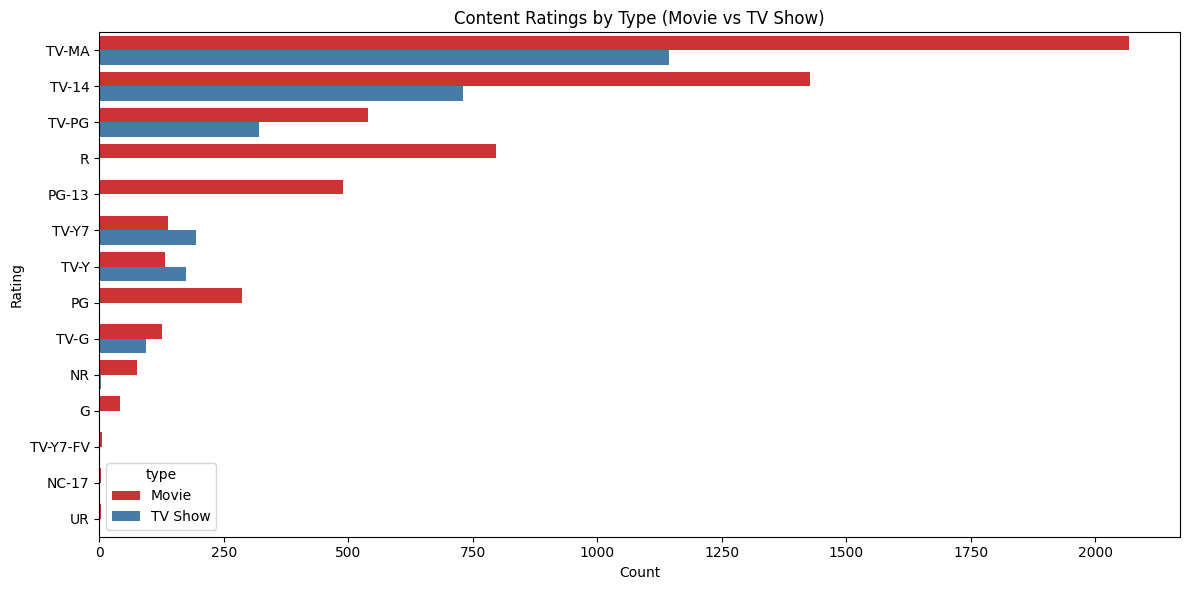

In [19]:
# Bonus: split by content type to see if Movies vs TV Shows skew differently
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='rating', hue='type', order=df['rating'].value_counts().index,
              palette='Set1')
plt.title('Content Ratings by Type (Movie vs TV Show)')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

In [20]:
# 1. Top 10 genres
# 'listed_in' has multiple genres per row (comma-separated), same approach as country
all_genres = df['listed_in'].str.split(', ').explode()

top10_genres = all_genres.value_counts().head(10)
print(top10_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [21]:
# 2. Most popular genre category
print("\nMost popular genre:", top10_genres.idxmax(), "with", top10_genres.max(), "titles")


Most popular genre: International Movies with 2752 titles


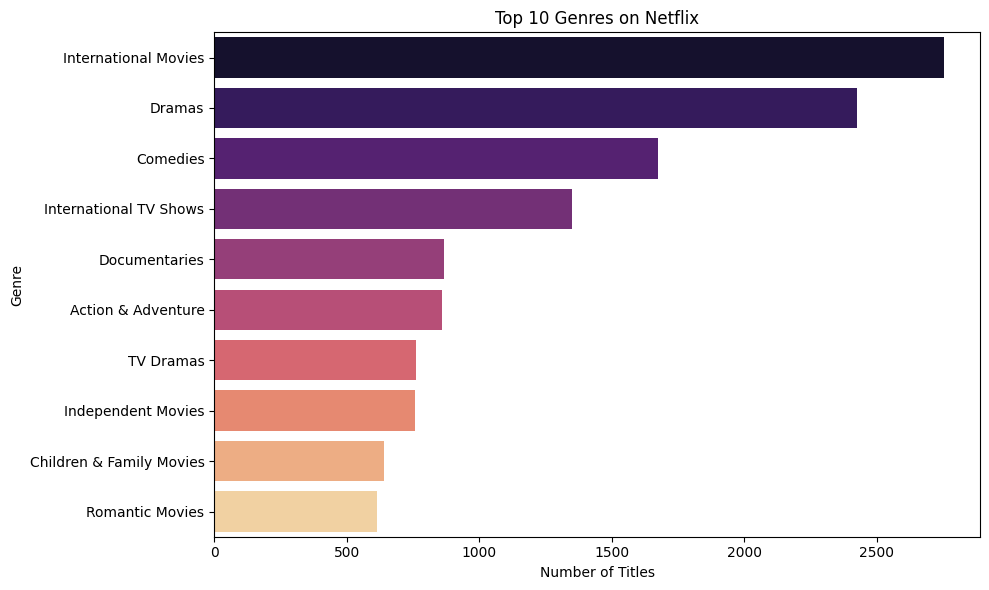

In [22]:
# 3. Visualize
plt.figure(figsize=(10,6))
sns.barplot(x=top10_genres.values, y=top10_genres.index, hue=top10_genres.index,
            palette='magma', legend=False)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [23]:
# Bonus: genre split by content type (Movies vs TV Shows) - top 5 only for readability
movie_genres = df[df['type']=='Movie']['listed_in'].str.split(', ').explode().value_counts().head(5)
tv_genres = df[df['type']=='TV Show']['listed_in'].str.split(', ').explode().value_counts().head(5)

print("Top 5 Movie genres:\n", movie_genres)
print("\nTop 5 TV Show genres:\n", tv_genres)

Top 5 Movie genres:
 listed_in
International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64

Top 5 TV Show genres:
 listed_in
International TV Shows    1350
TV Dramas                  762
TV Comedies                574
Crime TV Shows             469
Kids' TV                   449
Name: count, dtype: int64


In [25]:
movies = df[df['type'] == 'Movie'].copy()

# 1. Average movie duration
avg_duration = movies['duration_num'].mean()
print("Average movie duration:", round(avg_duration, 2), "minutes")

# 2. Longest movie
longest = movies.loc[movies['duration_num'].idxmax()]
print("\nLongest movie:\n", longest[['title','duration_num','release_year','listed_in']])

# 3. Shortest movie
shortest = movies.loc[movies['duration_num'].idxmin()]
print("\nShortest movie:\n", shortest[['title','duration_num','release_year','listed_in']])

Average movie duration: 99.56 minutes

Longest movie:
 title                               Black Mirror: Bandersnatch
duration_num                                               312
release_year                                              2018
listed_in       Dramas, International Movies, Sci-Fi & Fantasy
Name: 4253, dtype: object

Shortest movie:
 title                                               Silent
duration_num                                             3
release_year                                          2014
listed_in       Children & Family Movies, Sci-Fi & Fantasy
Name: 3777, dtype: object


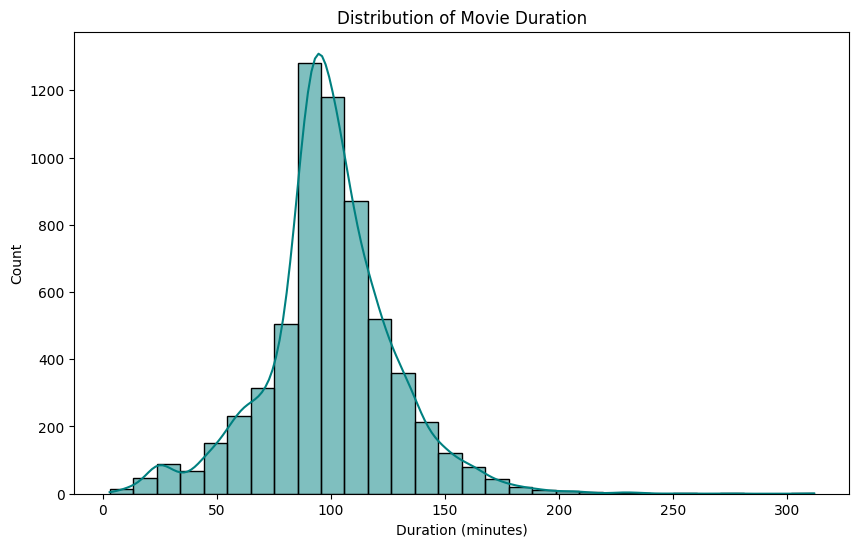

In [26]:
# 4. Distribution of movie duration

# Histogram
plt.figure(figsize=(10,6))
sns.histplot(movies['duration_num'], bins=30, kde=True, color='teal')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

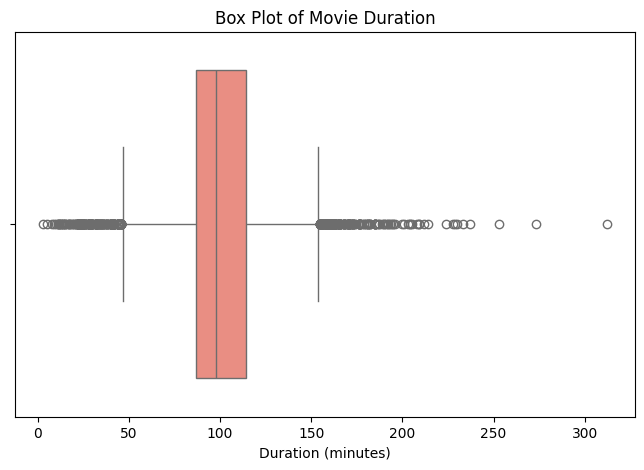

In [27]:
# Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x=movies['duration_num'], color='salmon')
plt.title('Box Plot of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.show()

In [28]:
from scipy import stats

# Method 1: IQR
Q1 = movies['duration_num'].quantile(0.25)
Q3 = movies['duration_num'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"IQR bounds: [{lower_bound}, {upper_bound}]")

iqr_outliers = movies[(movies['duration_num'] < lower_bound) | (movies['duration_num'] > upper_bound)]
print(f"\nNumber of IQR outliers: {len(iqr_outliers)}")
print(iqr_outliers[['title','duration_num']].sort_values('duration_num'))

Q1=87.0, Q3=114.0, IQR=27.0
IQR bounds: [46.5, 154.5]

Number of IQR outliers: 450
                                                 title  duration_num
3777                                            Silent             3
2713                                       Sol Levante             5
1484                                  Cops and Robbers             8
1557                                            Canvas             9
3535  American Factory: A Conversation with the Obamas            10
...                                                ...           ...
2484                                Lock Your Girls In           233
2487                                    No Longer kids           237
2491                            The School of Mischief           253
717                        Headspace: Unwind Your Mind           273
4253                        Black Mirror: Bandersnatch           312

[450 rows x 2 columns]


In [29]:
# Method 2: Z-score
movies['z_score'] = stats.zscore(movies['duration_num'])

z_outliers = movies[movies['z_score'].abs() > 3]
print(f"Number of Z-score outliers (|z| > 3): {len(z_outliers)}")
print(z_outliers[['title','duration_num','z_score']].sort_values('duration_num'))

Number of Z-score outliers (|z| > 3): 56
                                                  title  duration_num  \
3777                                             Silent             3   
2713                                        Sol Levante             5   
1484                                   Cops and Robbers             8   
1557                                             Canvas             9   
3535   American Factory: A Conversation with the Obamas            10   
6405                  Calico Critters: A Town of Dreams            11   
2858  Calico Critters: Everyone's Big Dream Flying i...            11   
695                                      Besieged Bread            12   
3775                     Cosmos Laundromat: First Cycle            12   
4707                                               Zion            12   
694                                               Aziza            13   
1669                     If Anything Happens I Love You            13   
71        

In [30]:
# 3. Compare results
print("IQR outliers count:", len(iqr_outliers))
print("Z-score outliers count:", len(z_outliers))

iqr_titles = set(iqr_outliers['title'])
z_titles = set(z_outliers['title'])

print("\nOutliers caught by BOTH methods:", len(iqr_titles & z_titles))
print("Outliers caught ONLY by IQR:", len(iqr_titles - z_titles))
print("Outliers caught ONLY by Z-score:", len(z_titles - iqr_titles))

IQR outliers count: 450
Z-score outliers count: 56

Outliers caught by BOTH methods: 56
Outliers caught ONLY by IQR: 394
Outliers caught ONLY by Z-score: 0


In [31]:
# 1. Release Decade
def get_decade(year):
    if year < 1990:
        return 'Pre-1980s'
    elif year < 2000:
        return '1980s'
    elif year < 2010:
        return '1990s'
    elif year < 2020:
        return '2000s' if year < 2010 else '2010s'
    else:
        return '2020s'

# Cleaner version using integer division
df['release_decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

print(df['release_decade'].value_counts().sort_index())

release_decade
1920s       1
1940s      15
1950s      11
1960s      25
1970s      70
1980s     129
1990s     274
2000s     807
2010s    5920
2020s    1545
Name: count, dtype: int64


In [32]:
# 2. Content Age
current_year = 2024  # or use datetime.now().year for the actual current year
df['content_age'] = current_year - df['release_year']

print(df[['title','release_year','content_age']].sample(5))

                                         title  release_year  content_age
1640                            Over Christmas          2020            4
1971                          Bhaji In Problem          2013           11
1617  Natalie Palamides: Nate - A One Man Show          2020            4
7024                                  Humsafar          2011           13
1528                                    Run On          2020            4


In [33]:
# 3. Duration Category (Movies only - Short/Medium/Long)
def duration_category(row):
    if row['type'] == 'TV Show':
        return 'N/A'
    elif row['duration_num'] < 60:
        return 'Short'
    elif row['duration_num'] <= 120:
        return 'Medium'
    else:
        return 'Long'

df['duration_category'] = df.apply(duration_category, axis=1)

print(df[df['type']=='Movie']['duration_category'].value_counts())

duration_category
Medium    4531
Long      1142
Short      458
Name: count, dtype: int64



--- Release Decade Distribution ---
release_decade
1920s       1
1940s      15
1950s      11
1960s      25
1970s      70
1980s     129
1990s     274
2000s     807
2010s    5920
2020s    1545
Name: count, dtype: int64

--- Duration Category Distribution (Movies) ---
duration_category
Medium    4531
Long      1142
Short      458
Name: count, dtype: int64


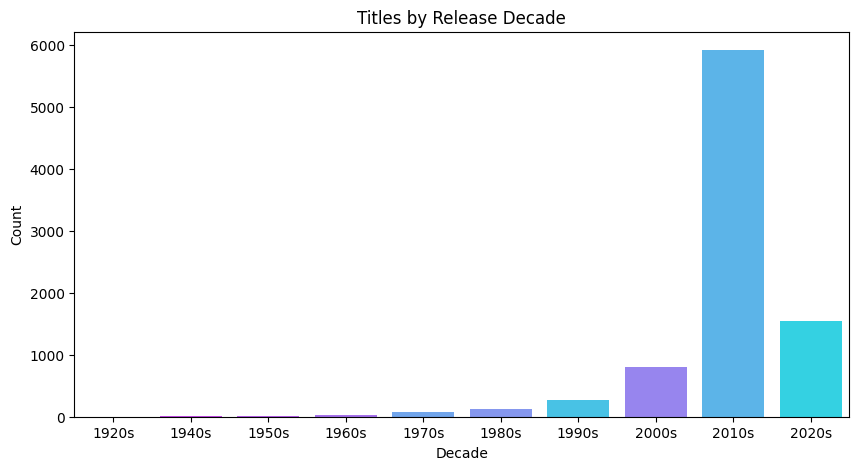

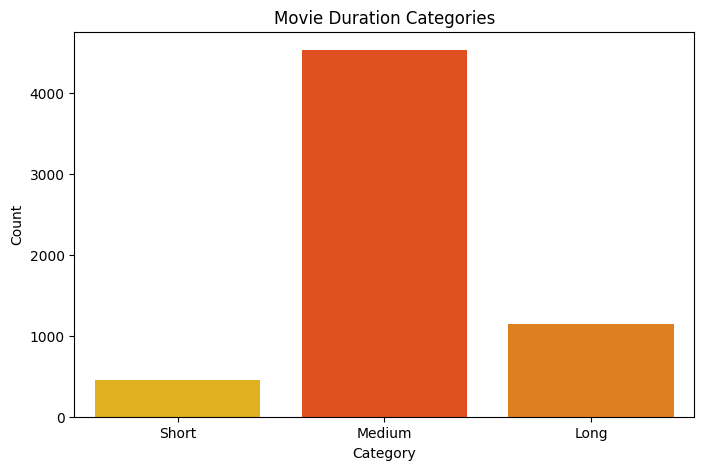

In [34]:
# Analyze the new features
print("\n--- Release Decade Distribution ---")
print(df['release_decade'].value_counts().sort_index())

print("\n--- Duration Category Distribution (Movies) ---")
print(df[df['type']=='Movie']['duration_category'].value_counts())

# Visualize
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='release_decade', hue='release_decade', order=sorted(df['release_decade'].unique()), palette='cool', legend=False)
plt.title('Titles by Release Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df[df['type']=='Movie'], x='duration_category', hue='duration_category',
              order=['Short','Medium','Long'], palette='autumn', legend=False)
plt.title('Movie Duration Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [35]:
# 1. Country vs Content Type (using exploded countries, excluding Unknown, top 10 only for readability)
df_exploded = df.copy()
df_exploded['country'] = df_exploded['country'].str.split(', ')
df_exploded = df_exploded.explode('country')
df_exploded = df_exploded[df_exploded['country'] != 'Unknown']

top10_country_list = df_exploded['country'].value_counts().head(10).index
country_type_data = df_exploded[df_exploded['country'].isin(top10_country_list)]

# Crosstab
country_type_crosstab = pd.crosstab(country_type_data['country'], country_type_data['type'])
print(country_type_crosstab)

type            Movie  TV Show
country                       
Canada            319      126
France            303       90
Germany           182       44
India             962       84
Japan             119      198
Mexico            111       58
South Korea        61      170
Spain             171       61
United Kingdom    532      271
United States    2751      932


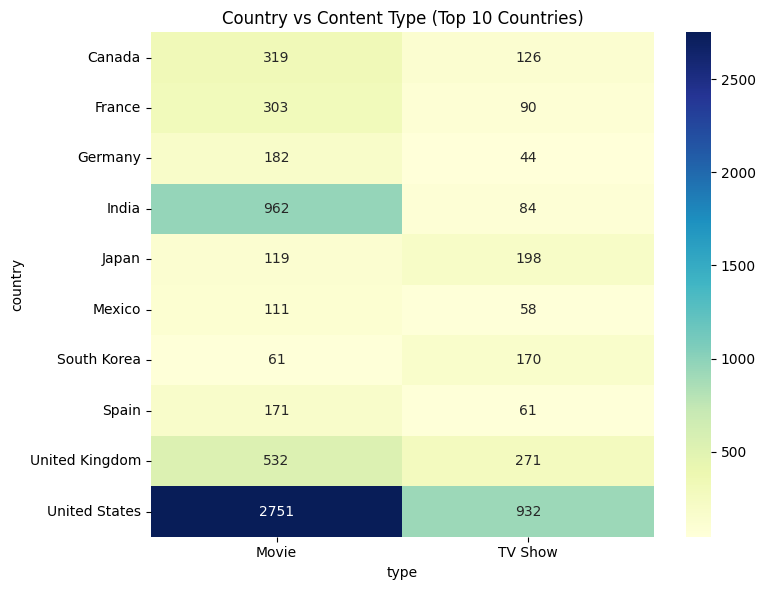

In [36]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(country_type_crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Country vs Content Type (Top 10 Countries)')
plt.tight_layout()
plt.show()

type          Movie  TV Show
release_year                
2010            154       39
2011            145       40
2012            173       63
2013            225       62
2014            264       88
2015            398      160
2016            658      243
2017            767      265
2018            767      379
2019            633      397
2020            517      436
2021            277      315


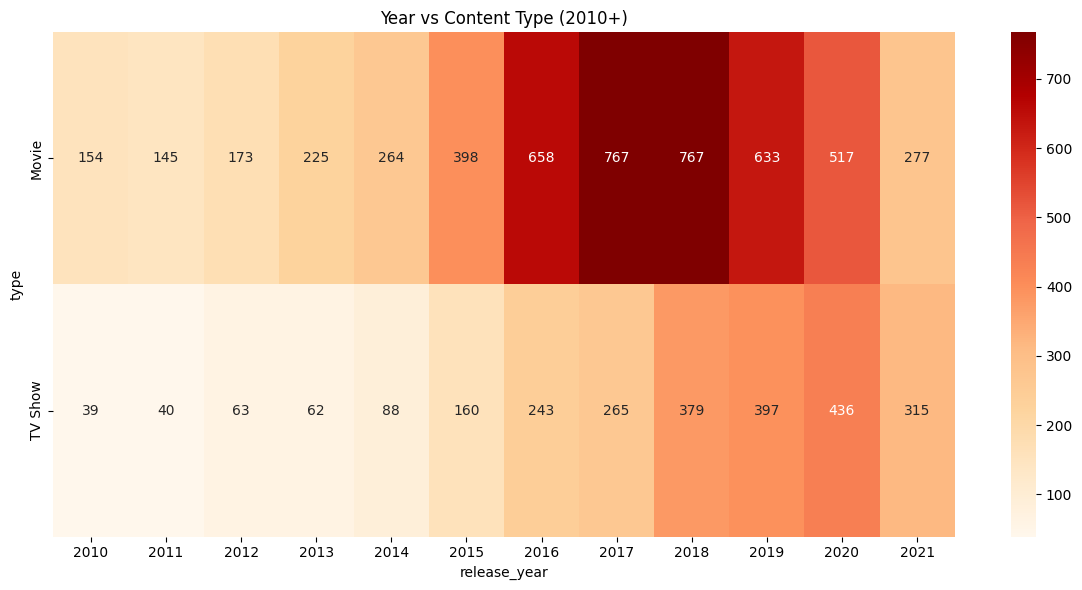

In [37]:
# 2. Year vs Content Type (using release_year, last 15 years for readability)
recent = df[df['release_year'] >= 2010]
year_type_crosstab = pd.crosstab(recent['release_year'], recent['type'])
print(year_type_crosstab)

plt.figure(figsize=(12,6))
sns.heatmap(year_type_crosstab.T, annot=True, fmt='d', cmap='OrRd')
plt.title('Year vs Content Type (2010+)')
plt.tight_layout()
plt.show()

type      Movie  TV Show
rating                  
G            41        0
NC-17         3        0
NR           75        4
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      730
TV-G        126       94
TV-MA      2067     1145
TV-PG       540      321
TV-Y        131      175
TV-Y7       139      194
TV-Y7-FV      5        1
UR            3        0


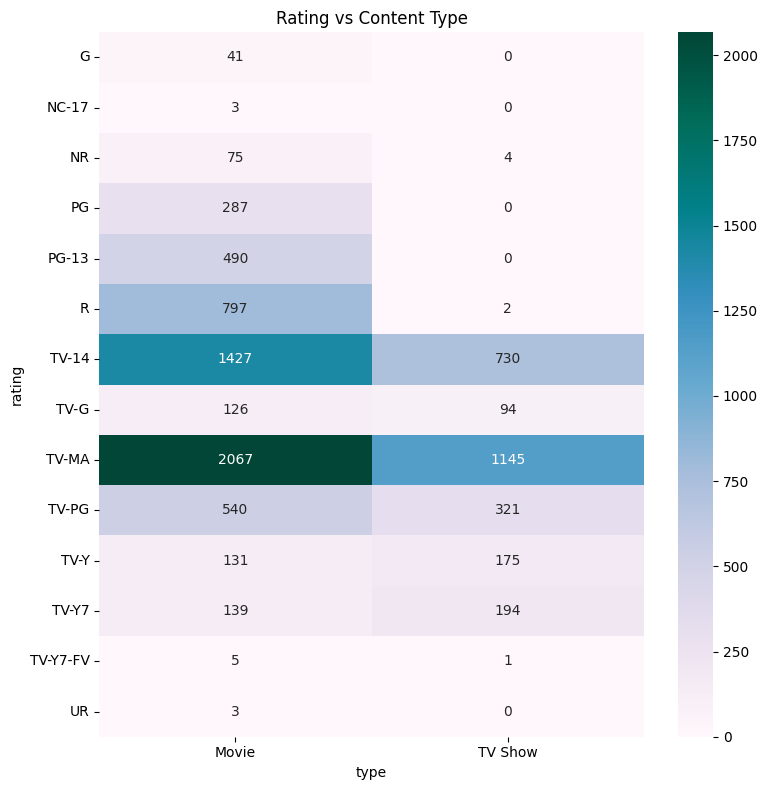

In [39]:
# 3. Rating vs Content Type
rating_type_crosstab = pd.crosstab(df['rating'], df['type'])
print(rating_type_crosstab)

plt.figure(figsize=(8,8))
sns.heatmap(rating_type_crosstab, annot=True, fmt='d', cmap='PuBuGn')
plt.title('Rating vs Content Type')
plt.tight_layout()
plt.show()

In [38]:
# GroupBy versions (as required by the task — alternative view to crosstab)
print("\nGroupBy: Country -> Type counts")
print(df_exploded[df_exploded['country'].isin(top10_country_list)].groupby(['country','type']).size())

print("\nGroupBy: Decade -> Type counts")
print(df.groupby(['release_decade','type'], observed=True).size())


GroupBy: Country -> Type counts
country         type   
Canada          Movie       319
                TV Show     126
France          Movie       303
                TV Show      90
Germany         Movie       182
                TV Show      44
India           Movie       962
                TV Show      84
Japan           Movie       119
                TV Show     198
Mexico          Movie       111
                TV Show      58
South Korea     Movie        61
                TV Show     170
Spain           Movie       171
                TV Show      61
United Kingdom  Movie       532
                TV Show     271
United States   Movie      2751
                TV Show     932
dtype: int64

GroupBy: Decade -> Type counts
release_decade  type   
1920s           TV Show       1
1940s           Movie        13
                TV Show       2
1950s           Movie        11
1960s           Movie        23
                TV Show       2
1970s           Movie        66
          